In [ ]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from preprocess import preprocess
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)

read the data from article_json

In [64]:
df = pd.read_json("../donnees/articles.json")

split the data

In [ ]:
X = df["body"]
y = df["categories"].str[0]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

preprocessing

In [70]:
X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)
df = df.map(lambda x: x.replace('\\"', '"').replace('"', '') if isinstance(x, str) else x)

 TF-IDF

In [71]:
vectorizer = TfidfVectorizer(
    min_df=2
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
predictions={}
predec_prob=[]
for categorie in label_set:
    i=0
    binary_categorie=[] 
    while i < len(y_train):
        if categorie == y_train.iloc[i]:
            binary_categorie.append(1)
        else:
            binary_categorie.append(0)
        i+=1
    lr_model = LogisticRegression()
    lr_model.fit(X_train_tfidf, binary_categorie)


    y_pred = lr_model.predict_proba(X_test_tfidf)[0][1]
    predictions[categorie] = float(y_pred)

    predec_prob.append(float(y_pred))
    


print(predictions)

In [72]:
from sklearn.metrics import f1_score
for C in [0.1, 1.0, 10]:
    
    lr_model = LogisticRegression(
        C=C,
        max_iter=10000
    )

    lr_model.fit(X_train_tfidf, y_train)

    y_pred = lr_model.predict(X_test_tfidf)

    print("C =", C)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(
        "Macro F1:",
        f1_score(y_test, y_pred, average="macro")
    )

C = 0.1
Accuracy: 0.8566666666666667
Macro F1: 0.8565024082093037
C = 1.0
Accuracy: 0.89125
Macro F1: 0.8911320699931142
C = 10
Accuracy: 0.8904166666666666
Macro F1: 0.8901589249348776


multiclass Logistic Regression

In [73]:
lr_model = LogisticRegression(
    max_iter=10000
)

lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

predictions

In [74]:
y_pred = lr_model.predict(X_test_tfidf)

Accuracy:

In [75]:
accuracy_score(y_test, y_pred)

0.89125

F1 per category:

In [84]:
print("\nF1 per category:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)


F1 per category:
              precision    recall  f1-score   support

      اقتصاد     0.8454    0.8750    0.8600       400
       ثقافة     0.9434    0.9175    0.9303       400
        دولي     0.8621    0.9375    0.8982       400
       رياضة     0.9899    0.9800    0.9849       400
       سياسة     0.8291    0.8250    0.8271       400
       مجتمع     0.8832    0.8125    0.8464       400

    accuracy                         0.8912      2400
   macro avg     0.8922    0.8912    0.8911      2400
weighted avg     0.8922    0.8912    0.8911      2400



Classification report:

In [76]:
confusion_matrix(y_test, y_pred)

array([[350,   7,   6,   0,  26,  11],
       [ 14, 367,   6,   0,   6,   7],
       [  7,   3, 375,   2,   8,   5],
       [  1,   2,   3, 392,   0,   2],
       [ 21,   4,  26,   1, 330,  18],
       [ 21,   6,  19,   1,  28, 325]])

ConfusionMatrix plot:

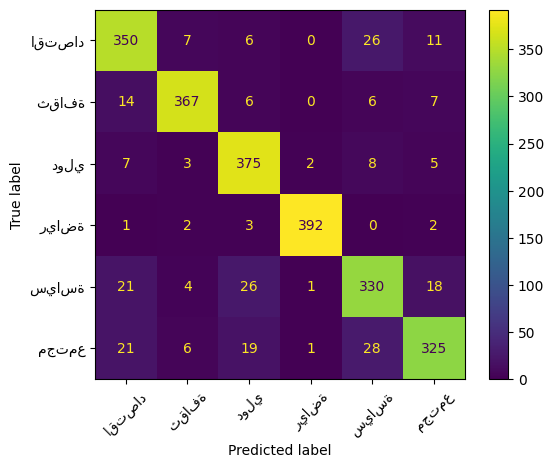

In [77]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)

In [78]:
feature_names = vectorizer.get_feature_names_out() 
 
for class_index, category in enumerate(lr_model.classes_): 
 
    weights = lr_model.coef_[class_index] 
 
    top_indices = weights.argsort()[-10:][::-1] 
 
    print(f"\nCategory: {category}") 
 
    for index in top_indices: 
        print(feature_names[index], weights[index]) 


Category: اقتصاد
شركة 4.2069316364919
قطاع 3.132093769047031
مغرب 3.021449431663587
درهم 2.959158480834925
سوق 2.654219085711262
مالية 2.5514275563358018
صندوق 2.357162432671726
بنك 2.337098299175506
اسعار 2.3062641708849263
مائة 2.2655899306733573

Category: ثقافة
اغنية 4.6428722531619195
مهرجان 4.481839699080781
فنان 4.399771269686623
فيلم 3.9259396947794776
ثقافة 3.787478322601251
فنية 3.616850085221961
فنانة 3.2270466350787905
ثقافي 3.2181182142340767
حفل 2.5337485511777955
فن 2.5032325948055205

Category: دولي
بلاد 3.0444245480685965
سعودية 2.6798681733346275
شرطة 2.673162577243105
عاما 2.613814135426333
وقال 2.5994299818352875
ترامب 2.516983072743318
رئيس 2.516067476546699
بيان 2.125685929825883
جزائرية 1.897741238949171
اعلام 1.8773672709103502

Category: رياضة
فريق 6.2951610757876
ساعة 5.4806683907303615
قدم 5.084542060856939
لكرة 4.58987979257788
مباراة 4.213848357642251
لاعب 4.129288144297767
رياضي 3.886206106181801
منتخب 3.610693070743757
رجاء 3.549091903181295
نادي 3.46050

In [79]:
print("Number of features:", len(vectorizer.get_feature_names_out()))

Number of features: 54615


Accuracy:
0.89125

Macro F1:
0.8911320699931142

F1 per category:
              precision    recall  f1-score   support

      اقتصاد     0.8454    0.8750    0.8600       400
       ثقافة     0.9434    0.9175    0.9303       400
        دولي     0.8621    0.9375    0.8982       400
       رياضة     0.9899    0.9800    0.9849       400
       سياسة     0.8291    0.8250    0.8271       400
       مجتمع     0.8832    0.8125    0.8464       400

    accuracy                         0.8912      2400
   macro avg     0.8922    0.8912    0.8911      2400
weighted avg     0.8922    0.8912    0.8911      2400


Confusion matrix:
[[350   7   6   0  26  11]
 [ 14 367   6   0   6   7]
 [  7   3 375   2   8   5]
 [  1   2   3 392   0   2]
 [ 21   4  26   1 330  18]
 [ 21   6  19   1  28 325]]


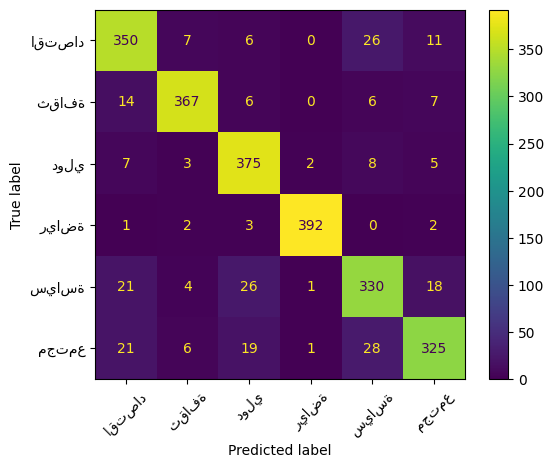

In [81]:
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

print("\nMacro F1:")
print(f1_score(y_test, y_pred, average="macro"))

print("\nF1 per category:")
print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation=45
)